# Protein Tertiary Structure Data Preprocessing

This notebook focuses on preprocessing the CASP protein tertiary structure dataset before machine learning model development.

Data preprocessing is an essential step in machine learning because it improves data quality, ensures consistency, and helps models learn meaningful patterns more effectively.

The preprocessing workflow includes:

1. Data loading  
2. Duplicate removal  
3. Missing value inspection  
4. Exploratory data analysis  
5. Correlation analysis  
6. Feature scaling  
7. Data preparation for machine learning


## Importing Libraries and Loading the Dataset

The required Python libraries are imported and the CASP dataset is loaded into a Pandas DataFrame for preprocessing and exploratory analysis.


In [2]:
import pandas as pd
df = pd.read_csv('../data/CASP.csv')

In [3]:
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


## Dataset Inspection

Initial inspection of the dataset helps identify the number of samples, features, and overall dataset structure.


In [4]:
df.shape

(45730, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45730 entries, 0 to 45729
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RMSD    45730 non-null  float64
 1   F1      45730 non-null  float64
 2   F2      45730 non-null  float64
 3   F3      45730 non-null  float64
 4   F4      45730 non-null  float64
 5   F5      45730 non-null  float64
 6   F6      45730 non-null  float64
 7   F7      45730 non-null  float64
 8   F8      45730 non-null  int64  
 9   F9      45730 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 3.5 MB


## Data Cleaning

Duplicate rows and missing values are checked to improve data quality before further analysis.


In [6]:
# Check for duplicated values
df.duplicated().value_counts()

False    44019
True      1711
Name: count, dtype: int64

In [7]:
df = df.drop_duplicates()
df

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147
...,...,...,...,...,...,...,...,...,...,...
45724,11.354,9106.35,2553.61,0.28042,72.1356,1.231680e+06,124.9890,4440.33,90,36.7669
45725,3.762,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84,36.8036
45726,6.521,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54,36.0470
45728,9.791,8878.93,3055.78,0.34416,94.0314,1.242266e+06,115.1950,3421.79,41,35.6045


## Exploratory Data Analysis

Exploratory analysis helps reveal statistical properties and distributions within the dataset. Understanding feature behaviour is important because machine learning algorithms can be sensitive to skewed or highly variable data.


In [8]:
df.describe()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
count,44019.000000,44019.000000,44019.000000,44019.000000,44019.000000,4.401900e+04,44019.000000,44019.000000,44019.000000,44019.000000
mean,7.795829,9874.503445,3019.460210,0.302475,103.496111,1.368753e+06,145.669889,3992.357462,70.095300,34.522120
std,6.137803,4054.023208,1465.353353,0.063060,55.298130,5.635050e+05,69.869706,2006.910773,56.490249,5.978529
min,0.000000,2392.050000,403.500000,0.092500,10.310100,3.194902e+05,31.970400,0.000000,0.000000,15.228000
25%,2.313000,6940.705000,1979.515000,0.258580,63.606950,9.542189e+05,94.786400,3167.420000,31.000000,30.430250
50%,5.087000,8902.580000,2671.030000,0.300190,87.777800,1.238022e+06,126.218000,3840.540000,54.000000,35.301900
75%,13.465500,12124.450000,3789.575000,0.343075,133.614000,1.690883e+06,181.451000,4644.850000,91.000000,38.869550
max,20.999000,40034.900000,15312.000000,0.577690,369.317000,5.472011e+06,598.408000,105948.170000,350.000000,55.300900


## Data Cleaning and Preprocessing

After loading the dataset, the first step was to check for **missing values** and **duplicate entries** to ensure the quality of the analysis.

During this process, it was observed that the dataset contained duplicate rows, which could negatively affect the accuracy and reliability of the analysis. The original dataset had a shape of **(45,739, 10)**, meaning it contained **45,739 rows** and **10 columns**.

After checking for duplicates, a total of **1,711 duplicated rows** were identified. To avoid biased results and maintain data integrity, these duplicates were removed using the `df.drop_duplicates()` function, resulting in a cleaner dataset for further analysis and modeling.

## RMSD Distribution Analysis

The RMSD distribution provides insight into the target variable behaviour and helps identify skewness, outliers, or imbalance within the dataset.


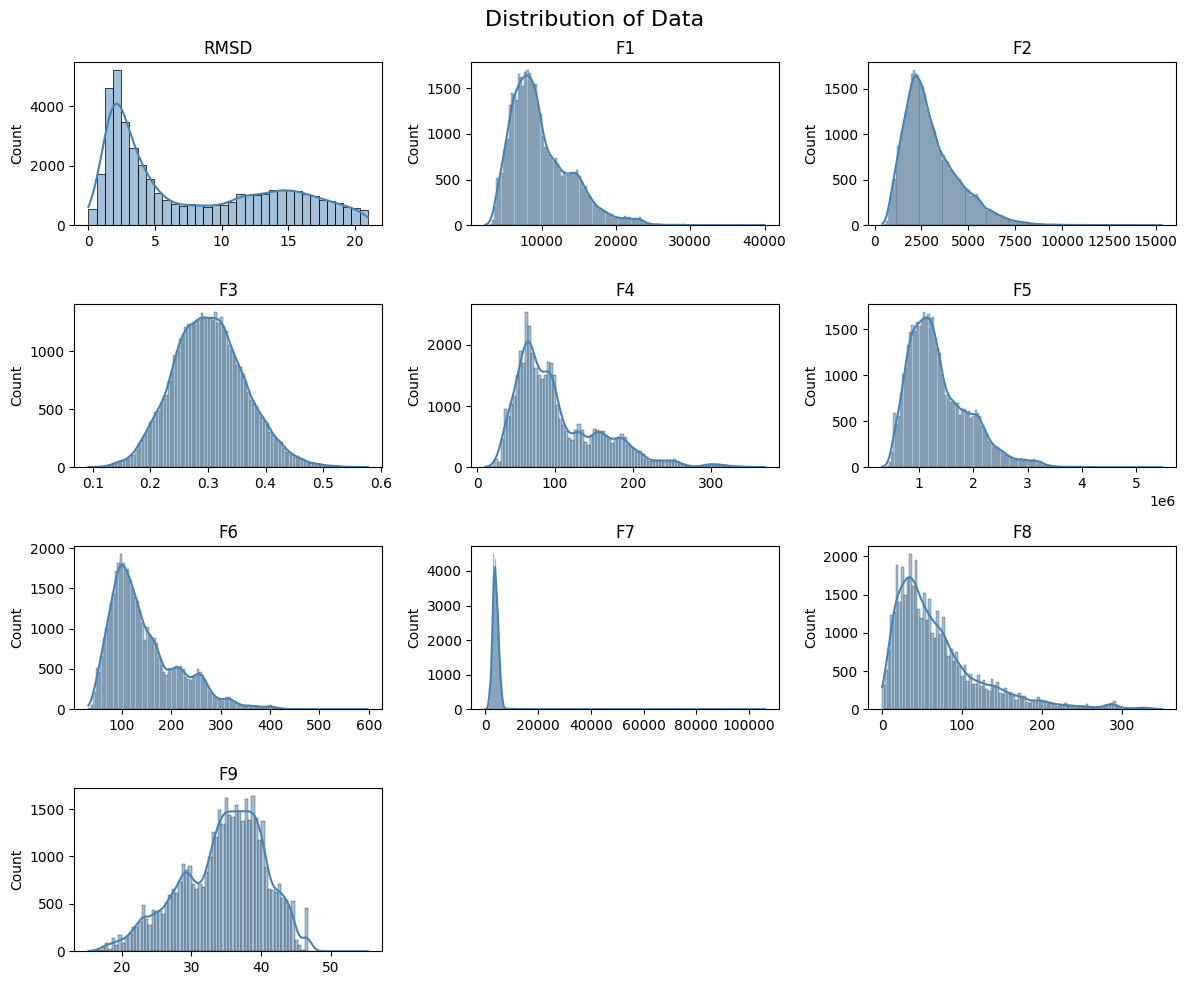

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is loaded like this:
# df = pd.read_csv('CASP.csv')

# 1. Setup the grid (3 columns x 4 rows = 12 possible slots for 10 columns)
fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(12, 10))
axes = axes.flatten()

# 2. Loop through your columns (F1 through F9, plus RMSD)
for i, col in enumerate(df.columns):
    # FIX: Pass 'ax=axes[i]' and explicitly state 'x=col'
    sns.histplot(data=df, x=col, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# 3. Hide the remaining 2 empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# FIX: Removed the stray closing parenthesis in the title string
plt.suptitle('Distribution of Data', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/meschacolongo/protein_tertiary_structure/images/distribution_of_data.png')
plt.show()

## Observations from the Histograms

After analyzing the histograms, several important observations can be made about the dataset:

- **RMSD**, which is the target variable, is **right-skewed**, with most values concentrated around smaller numbers.
- Other features such as **F8, F4, F1, and F6** also exhibit **right-skewed distributions**.
- Another important observation is that the features exist on **very different scales**. For example:
  - **F7** contains values reaching close to **100,000**
  - **F3** only ranges up to around **0.6**

Because of these large differences in scale, feature scaling is necessary. Without scaling, the model may place more importance on features with larger numerical values (such as **F7**) while underestimating the influence of smaller-scale features (such as **F3**).

## Feature Correlation Analysis

A correlation matrix is used to investigate relationships between variables. Strong correlations between features may indicate multicollinearity, which can affect linear regression models.


In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

RMSD       0
F1      1113
F2      1194
F3       354
F4      1172
F5      1028
F6      1249
F7       525
F8      2329
F9       147
dtype: int64


## Outlier Analysis Using IQR

After examining the Interquartile Range (IQR), it was observed that several features contain outliers. However, these outliers were not removed for the following reasons:

- The dataset is sufficiently large, meaning the outliers represent only a small proportion of the total observations.
- The values correspond to real biological measurements. Therefore, extreme values may reflect genuine biological variability rather than data entry or measurement errors.
- Removing outliers without proper domain knowledge could lead to the loss of meaningful biological information and potentially discard important signals within the dataset.

For these reasons, the outliers were retained in the analysis to preserve the integrity and variability of the biological data.

## Feature Scaling

Feature scaling is performed to place numerical variables on a similar scale. This is especially important for models such as Ridge and Lasso Regression.


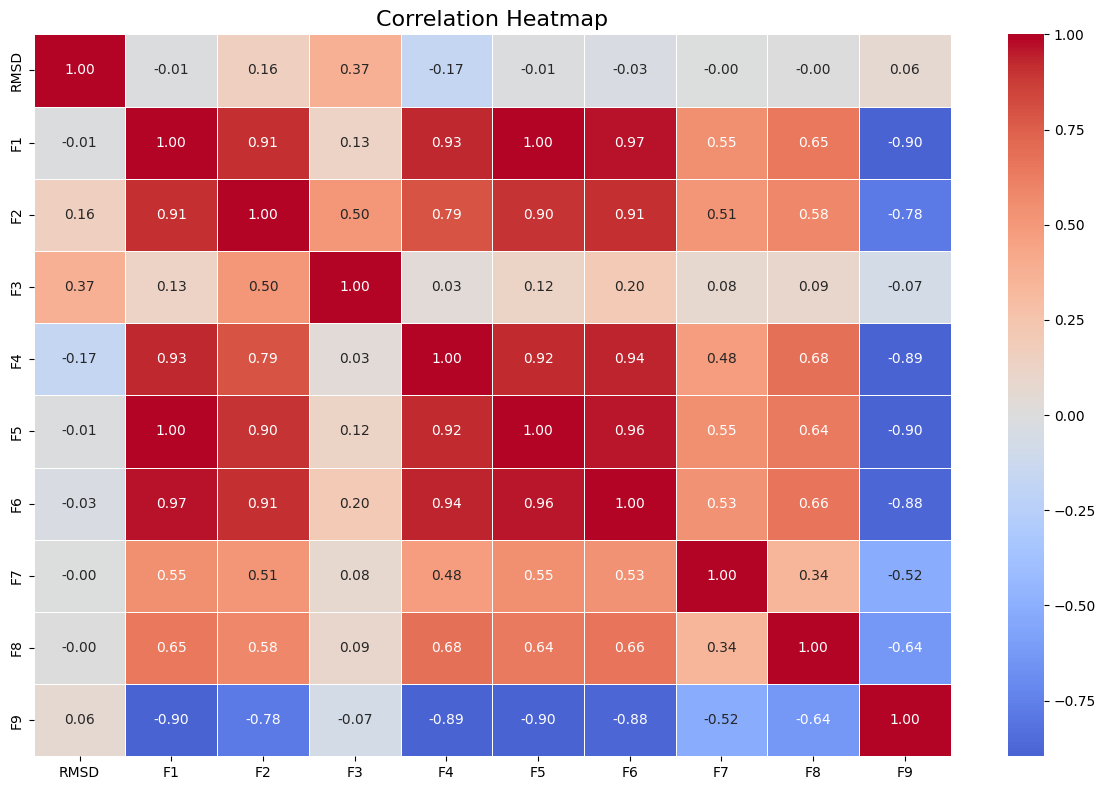

In [12]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center = 0, 
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('/Users/meschacolongo/protein_tertiary_structure/images/correlation_heatmap.png')
plt.show()

## Correlation Analysis and Model Selection

After examining the correlation matrix, it became clear that many of the features are strongly correlated with one another. This indicates the presence of **multicollinearity** within the dataset. Because of this, using a model such as **Linear Regression** to determine which features most influence **RMSD** would not be ideal. Linear models often struggle to clearly separate the individual effects of highly correlated variables, which can result in unstable coefficients and misleading interpretations of feature importance.

From a biological perspective, it is also reasonable for many of these variables to be correlated, as biological systems are highly interconnected and interdependent.

In addition, the exploratory data analysis revealed:
- Strong multicollinearity between features
- Non-linear and bimodal feature distributions
- Significant differences in feature scales
- The presence of biologically meaningful outliers

These observations suggest that a **tree-based model** would likely perform better than traditional linear approaches. As a result, **Random Forest Regression** was selected as the primary model for this project because of its ability to handle non-linear relationships, correlated features, and complex interactions within the data.

To provide a baseline comparison, **Ridge Regression** and **Lasso Regression** were also included as regularized linear models.

With the exploratory data analysis completed, the next step is to proceed with model training and evaluation.

## Preprocessing Summary

The preprocessing stage revealed that the dataset contains complex feature relationships and a non-uniform RMSD distribution. Several features were strongly correlated, suggesting the presence of multicollinearity.

Additionally, the RMSD distribution appeared right-skewed, indicating that extreme RMSD values are less frequent within the dataset. These characteristics suggest that non-linear machine learning models may perform better than purely linear approaches.

The dataset is now cleaned, scaled, and properly structured for machine learning model development.
